In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
from os.path import sep

In [2]:
from fly2p_function_TQ.imaging_2_bridge_analysis import get_2_bridge_data_for_analysis

In [3]:
fly_data = get_2_bridge_data_for_analysis('/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/EPG_imaging_delta7_perturbation/shi/R27F02_lexop7b_R55G08_shi/cl-31')

In [4]:
fly_data_2 = get_2_bridge_data_for_analysis('/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/EPG_imaging_delta7_perturbation/shi/R27F02_lexop7b_empty_shi/cl-31')

In [5]:
def plot_pva_strength_distribution(fly_data, bins=40, combine_sides=True):
    """
    Plot distributions of PVA_strength across all flies.

    Args:
        fly_data (dict): dictionary with fly IDs as keys and each entry containing
                         'PVA_strength_left_bridge' and 'PVA_strength_right_bridge'.
        bins (int): number of bins for histogram.
        combine_sides (bool): if True, combine left+right into one distribution per fly.
                              if False, plot left and right separately.
    """
    plt.figure(figsize=(10,6))

    for fly_id, data in fly_data.items():
        left = np.ravel(data.get("PVA_strength_left_bridge", []))
        right = np.ravel(data.get("PVA_strength_right_bridge", []))

        if combine_sides:
            combined = np.concatenate([left, right])
            sns.histplot(combined, bins=bins, stat="density", kde=True, 
                         label=f"{fly_id}", element="step", fill=False, alpha=0.7)
        else:
            if len(left) > 0:
                sns.histplot(left, bins=bins, stat="density", kde=True, 
                             label=f"{fly_id} (left)", element="step", fill=False, alpha=0.7)
            if len(right) > 0:
                sns.histplot(right, bins=bins, stat="density", kde=True, 
                             label=f"{fly_id} (right)", element="step", fill=False, alpha=0.7)

    plt.xlabel("PVA Strength")
    plt.ylabel("Density")
    plt.title("Distribution of PVA Strength across flies")
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def _base_id(trial_id):
    return trial_id.rsplit("-", 1)[0] if isinstance(trial_id, str) and "-" in trial_id else trial_id

def _per_fly_means_from_group_FWHM(group_dict, combine_sides=True):
    """
    Returns per-fly FWHM values.

    If combine_sides=True:
        - For each TRIAL: concat left+right samples, take trial mean.
        - For each FLY:   mean across its trial means -> 1 value per fly.

    If combine_sides=False:
        - For each TRIAL: compute left-trial-mean and right-trial-mean separately (if present).
        - For each FLY:   mean of its left-trial-means (-> one left value)
                          and mean of its right-trial-means (-> one right value).
        - Returns concatenated list [all left means, all right means], so flies can contribute 2 dots.
    """
    if not group_dict:
        return [], []

    if combine_sides:
        per_fly_trial_means = {}
        for trial_id, d in group_dict.items():
            L = np.ravel(d.get("FWHM_left_bridge", []))
            R = np.ravel(d.get("FWHM_right_bridge", []))
            arr = np.concatenate([L, R]) if (L.size + R.size) else np.array([])
            if arr.size == 0 or not np.any(np.isfinite(arr)):
                continue
            trial_mean = float(np.nanmean(arr))
            fid = _base_id(trial_id)
            per_fly_trial_means.setdefault(fid, []).append(trial_mean)
        fly_vals = [float(np.nanmean(v)) for v in per_fly_trial_means.values()]
        fly_ids  = list(per_fly_trial_means.keys())
        return fly_ids, fly_vals

    # separate sides
    per_fly_left_means  = {}
    per_fly_right_means = {}
    for trial_id, d in group_dict.items():
        L = np.ravel(d.get("FWHM_dff_left_bridge", []))
        R = np.ravel(d.get("FWHM_dff_right_bridge", []))
        fid = _base_id(trial_id)
        if L.size and np.any(np.isfinite(L)):
            per_fly_left_means.setdefault(fid, []).append(float(np.nanmean(L)))
        if R.size and np.any(np.isfinite(R)):
            per_fly_right_means.setdefault(fid, []).append(float(np.nanmean(R)))

    # average across trials per side
    fly_vals = []
    for fid, arr in per_fly_left_means.items():
        fly_vals.append(float(np.nanmean(arr)))
    for fid, arr in per_fly_right_means.items():
        fly_vals.append(float(np.nanmean(arr)))

    # ids are optional for plotting; return combined list
    fly_ids = list(per_fly_left_means.keys()) + list(per_fly_right_means.keys())
    return fly_ids, fly_vals

def _sem(a):
    a = np.asarray(a, float)
    a = a[np.isfinite(a)]
    if a.size <= 1: return 0.0
    return float(np.nanstd(a, ddof=1) / np.sqrt(a.size))

def _mwu_star(p):
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

def _pairwise_mwu_bh(xs, labels):
    from itertools import combinations
    pairs = list(combinations(range(len(xs)), 2))
    raw = []
    for i, j in pairs:
        xi = np.asarray(xs[i], float); yi = np.asarray(xs[j], float)
        xi = xi[np.isfinite(xi)]; yi = yi[np.isfinite(yi)]
        if xi.size and yi.size:
            _, p = stats.mannwhitneyu(xi, yi, alternative='two-sided')
        else:
            p = np.nan
        raw.append(p)
    p_arr = np.array(raw, float)
    order = np.argsort(np.nan_to_num(p_arr, nan=np.inf))
    m = len(p_arr); q = np.full(m, np.nan); running = np.inf
    for k in range(m-1, -1, -1):
        idx = order[k]; p = p_arr[idx]
        if np.isfinite(p):
            val = p * m / (k+1); running = min(running, val); q[idx] = min(1.0, running)
    out = []
    for (i,j), p, qq in zip(pairs, p_arr, q):
        out.append({"group_i": labels[i], "group_j": labels[j],
                    "p_mwu": float(p) if np.isfinite(p) else np.nan,
                    "q_bh": float(qq) if np.isfinite(qq) else np.nan})
    return out

def plot_fwhm_compare_per_fly_means(
    data1=None, data2=None, data3=None, data4=None,
    labels=("Control", "Δ7-shi", "Group 3", "Group 4"),
    # palette tuned to your mock: warm gray + teal
    colors=("#6A6A6A", "#2B8C83", "#99C24D", "#F6AE2D"),
    combine_sides=True,
    ylabel="FWHM (°)",
    title=None,                  # top-center stars are used for 2 groups; omit title by default
    jitter=0.12,
    point_size=70,
    point_alpha=0.95,
    edgecolor=None,              # None → auto darker edge; "" to disable
    edgewidth=0.8,
    mean_width=0.55,             # fraction of group spacing for the mean bar
    mean_lw=5.0,                 # thickness of the mean bar
    fontsize=16,
    ylim=None,                   # e.g., (140, 205)
    star_y_pad=0.08,             # padding (fraction of y-range) above max point for stars
    bracket=False,               # show only stars (like your figure); set True to draw bracket
    return_stats=True
):
    groups = [g for g in (data1, data2, data3, data4) if g is not None]
    if not groups:
        print("No groups provided.")
        return None
    glabels = labels[:len(groups)]
    gcolors = colors[:len(groups)]

    # collect values per group
    per_group = []
    ns = []
    for G in groups:
        _, vals = _per_fly_means_from_group_FWHM(G, combine_sides=combine_sides)
        vals = np.asarray(vals, float)
        vals = vals[np.isfinite(vals)]
        per_group.append(vals)
        ns.append(int(vals.size))

    # figure
    fig, ax = plt.subplots(figsize=(0.5 + 1.2*len(groups), 4.5), dpi=150)
    xlocs = np.arange(1, len(groups)+1)

    # scatter + colored mean bars
    overall_max = -np.inf
    overall_min = np.inf
    for i, (x, vals, col, n) in enumerate(zip(xlocs, per_group, gcolors, ns)):
        if vals.size:
            overall_max = max(overall_max, np.max(vals))
            overall_min = min(overall_min, np.min(vals))

        rng = np.random.default_rng(10_007 + i)
        xj = x + rng.uniform(-jitter, jitter, size=vals.size)

        # auto edge color: darker version of fill
        ec = edgecolor
        if ec is None:
            # simple darker outline by blending toward black
            from matplotlib.colors import to_rgb
            r,g,b = to_rgb(col)
            ec = (0.55*r, 0.55*g, 0.55*b)

        ax.scatter(
            xj, vals,
            s=point_size, c=col, alpha=point_alpha,
            edgecolor=("none" if edgecolor == "" else ec),
            linewidth=edgewidth, zorder=3
        )

        # mean line (colored, horizontal)
        if vals.size:
            m = float(np.nanmean(vals))
            halfw = mean_width * 0.5
            ax.hlines(m, x - halfw, x + halfw, color=col, linewidth=mean_lw, zorder=4)

    # axes cosmetics like your example
    ax.set_xticks(xlocs)
    ax.set_xticklabels([f"{lab}" for lab in glabels], fontsize=fontsize, rotation=35, ha="right")
    ax.set_ylabel(ylabel, fontsize=fontsize+1)

    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        # a bit of breathing room
        if np.isfinite(overall_min) and np.isfinite(overall_max):
            yr = overall_max - overall_min if overall_max > overall_min else 1.0
            ax.set_ylim(overall_min - 0.08*yr, overall_max + 0.20*yr)

    # remove top/right, thicken left/bottom
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2.0)
    ax.spines["bottom"].set_linewidth(2.0)
    ax.tick_params(axis='y', labelsize=fontsize-1)
    ax.tick_params(axis='x', width=1.6)

    # no grid, no legend, clean layout
    if title:
        ax.set_title(title, fontsize=fontsize+3, pad=8)

    # stats: for 2 groups, show centered stars at top like your figure
    stats_out = None
    if return_stats:
        stats_out = {"per_group": {}, "omnibus": {}, "pairwise": []}
        for lab, vals in zip(glabels, per_group):
            v = vals[np.isfinite(vals)]
            stats_out["per_group"][lab] = {
                "n": int(v.size),
                "mean": float(np.nanmean(v)) if v.size else np.nan,
                "sem": float(np.nanstd(v, ddof=1)/np.sqrt(v.size)) if v.size > 1 else 0.0
            }

        finite = [v[np.isfinite(v)] for v in per_group]
        if len(finite) == 2:
            x, y = finite
            p = stats.mannwhitneyu(x, y, alternative='two-sided')[1] if (x.size and y.size) else np.nan
            stats_out["omnibus"] = {"mannwhitney_p": float(p)}

            if np.isfinite(p):
                star = "***" if p < 1e-3 else ("**" if p < 1e-2 else ("*" if p < 5e-2 else "n.s."))
                # position stars centered
                y0, y1 = ax.get_ylim()
                ypad = star_y_pad * (y1 - y0)
                ystar = (max(np.max(x) if x.size else y0, np.max(y) if y.size else y0)
                         if (x.size or y.size) else y0) + ypad
                if bracket:
                    x1, x2 = xlocs[0], xlocs[1]
                    ax.plot([x1, x1, x2, x2], [ystar, ystar+ypad*0.5, ystar+ypad*0.5, ystar],
                            color="k", lw=1.6)
                    ax.text((x1+x2)/2, ystar+ypad*0.65, star, ha="center", va="bottom",
                            fontsize=fontsize+4, color="k")
                    ax.set_ylim(y0, ystar + 2.2*ypad)
                else:
                    # stars only, centered (like your example)
                    ax.text((xlocs[0]+xlocs[-1])/2, ystar+ypad*0.4, star,
                            ha="center", va="bottom", fontsize=fontsize+6, color="k")
                    ax.set_ylim(y0, ystar + 2.0*ypad)
        else:
            usable = [v for v in finite if v.size]
            p_kw = stats.kruskal(*usable)[1] if len(usable) >= 2 else np.nan
            stats_out["omnibus"] = {"kruskal_p": float(p_kw)}
            # optional: add BH-corrected pairwise if you need; omitted on-plot for clean look

    plt.tight_layout()
    #plt.savefig('EPG_7b_delta7_shi_FWHM.svg', format='svg')
    plt.show()
    return stats_out




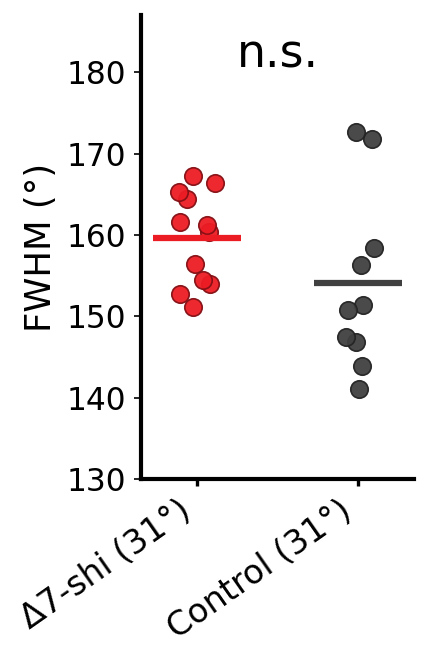

In [17]:
# 1–4 group dicts (keys are trial_ids → each has FWHM_left/right arrays)
stats_fwhm = plot_fwhm_compare_per_fly_means(
    data1=fly_data, data2=fly_data_2, data3=None, data4=None,
    labels=("Δ7-shi (31°)", "Control (31°)"),
    # palette tuned to your mock: warm gray + teal
    #colors=("#2B8C83", "#6A6A6A"),("#ec1c24","#404041"),("#faa51a", "#282a74") #("Δ7-shi (31°)", "Control (31°)")
    colors=("#ec1c24","#404041"),
    combine_sides=True,
    ylabel="FWHM (°)",
    title=None,                  # top-center stars are used for 2 groups; omit title by default
    jitter=0.12,
    point_size=70,
    point_alpha=0.95,
    edgecolor=None,              # None → auto darker edge; "" to disable
    edgewidth=0.8,
    mean_width=0.55,             # fraction of group spacing for the mean bar
    mean_lw=3.0,                 # thickness of the mean bar
    fontsize=16,
    ylim=(130,190),                   # e.g., (140, 205)
    star_y_pad=0.08,             # padding (fraction of y-range) above max point for stars
    bracket=False,               # show only stars (like your figure); set True to draw bracket
)



In [18]:
import numpy as np
import pandas as pd
from scipy.interpolate import splrep, splev

# ---------- helpers ----------

def _periodic_cubic(values8, up=10):
    """Upsample an 8-bin profile to a fine periodic grid (len = 8*up)."""
    y = np.asarray(values8, float).ravel()
    x = np.arange(8, dtype=float)
    # robust NaNs
    if np.any(~np.isfinite(y)):
        m = np.nanmean(y)
        if not np.isfinite(m): m = 0.0
        y = np.nan_to_num(y, nan=m)
    tck = splrep(x, y, s=0, k=3, per=True)
    x_fine = np.linspace(0.0, 8.0, num=8*up, endpoint=False)
    y_fine = splev(x_fine % 8.0, tck)
    return np.asarray(y_fine, float)

def _downsample_fine_to_8(y_fine, up=10):
    """Take a fine (8*up) vector back to 8 samples at integer glomeruli."""
    y = np.asarray(y_fine, float).ravel()
    assert y.size == 8*up, "fine vector must have length 8*up"
    return y[::up]

def circ_shift_8_integer(y8, shift_glom):
    """
    Circularly shift an 8-bin profile by an *integer* number of bins.
    Positive = right shift, Negative = left shift.
    """
    y8 = np.asarray(y8, float).ravel()
    assert y8.size == 8, "expected 8-bin vector"
    shift_glom = int(np.rint(shift_glom)) % 8
    return np.roll(y8, shift_glom)


def _speed_mask(angular_speed_deg, T, angular_speed_range):
    if angular_speed_range is None:
        return np.ones(T, dtype=bool)
    # normalize range
    if np.isscalar(angular_speed_range):
        low, high = 0.0, float(angular_speed_range)
    else:
        low, high = float(angular_speed_range[0]), float(angular_speed_range[1])
        if low > high: low, high = high, low
    if angular_speed_deg is None:
        return np.ones(T, dtype=bool)
    s = np.asarray(angular_speed_deg).ravel()
    if s.size != T:
        return np.ones(T, dtype=bool)
    s_abs = np.abs(s)
    return (s_abs >= low) & (s_abs <= high)

def _phase_from_fine(y_fine):
    """
    Weighted circular-mean phase on the fine grid.
    Input is fine (8*up) samples over 0..8 glomeruli → return phase in glomeruli (0..8).
    """
    y = np.asarray(y_fine, float).ravel()
    n = y.size
    w = y - np.nanmin(y)
    if not np.isfinite(w).all() or np.allclose(w.sum(), 0):
        w = np.ones_like(y) * 1e-6
    theta = 2.0 * np.pi * (np.arange(n) / float(n))  # 0..2π
    c = np.sum(w * np.exp(1j * theta))
    phase_rad = np.angle(c) % (2*np.pi)
    phase_glom = (phase_rad / (2*np.pi)) * 8.0
    return float(phase_glom % 8.0)

# ---------- core nulling on 8 bins (with optional fine output) ----------

def _phase_null_side_matrix(
    Z,
    angular_speed_deg=None,
    angular_speed_range=None,
    up=10,
    keep_stack=False,
    *,
    align_mode="phase",            # "phase" | "pva_roi"
    pva_roi=None,                  # length-T array of 0..7 if align_mode="pva_roi"
    target_glom=0.0,               # place phase/PVA at this glomerulus (default 0)
    return_fine=True,              # also return 8*up stacks reconstructed from shifted 8
    l1_norm_per_frame=True         # <<< NEW: L1-normalize each shifted frame BEFORE averaging
):
    """
    Phase/PVA null each frame by shifting the original 8-bin vector, then (optionally)
    L1-normalize each shifted frame (sum=1) BEFORE stacking/averaging.

    If align_mode='phase': estimate phase on a fine spline, then shift the 8-bin frame by that phase to target_glom.
    If align_mode='pva_roi': use given ROI index per frame (0..7), and shift the 8-bin frame accordingly.

    Outputs (same as before):
      - mean_8 (len=8)
      - if return_fine: mean_fine (len=8*up) reconstructed from shifted 8
      - optional stacks if keep_stack=True
    """
    Z = np.asarray(Z, float)
    T, C = Z.shape
    assert C % 8 == 0, "Columns must be a multiple of 8."
    K = C // 8

    sel = _speed_mask(angular_speed_deg, T, angular_speed_range)
    stack8 = []
    stack_fine = []

    # validate PVA ROI array if needed
    if align_mode == "pva_roi":
        if pva_roi is None:
            raise ValueError("align_mode='pva_roi' requires pva_roi array of length T.")
        pva_arr = np.asarray(pva_roi).ravel()
        if pva_arr.size != T:
            raise ValueError(f"pva_roi length {pva_arr.size} does not match T={T}.")
    else:
        pva_arr = None

    for k in range(K):
        block = Z[:, 8*k:8*(k+1)]  # (T x 8)
        for t in np.where(sel)[0]:
            frame8 = np.asarray(block[t, :], float).ravel()  # the 8-bin data

            # --- choose shift ---
            if align_mode == "pva_roi":
                g0 = pva_arr[t]
                if not np.isfinite(g0):
                    continue
                shift_glom = float(target_glom) - float(g0)   # move PVA-ROI to target_glom
            else:  # "phase"
                y_fine = _periodic_cubic(frame8, up=up)      # fine only to estimate phase
                phase_glom = _phase_from_fine(y_fine)
                shift_glom = float(target_glom) - float(phase_glom)

            # --- shift the original 8-bin frame ---
            frame8_aligned = circ_shift_8_integer(frame8, shift_glom=shift_glom)

            # --- L1 normalize per-frame AFTER nulling, BEFORE averaging ---
            if l1_norm_per_frame:
                # make nonnegative if needed (rare, but safe)
                m = np.nanmin(frame8_aligned)
                if np.isfinite(m) and m < 0:
                    frame8_aligned = frame8_aligned - m
                s = np.nansum(frame8_aligned)
                if np.isfinite(s) and s > 0:
                    frame8_aligned = frame8_aligned / s

            stack8.append(frame8_aligned)

            if return_fine:
                # reconstruct a fine trace from the shifted (and normalized) 8-bin
                stack_fine.append(_periodic_cubic(frame8_aligned, up=up))

    if len(stack8) == 0:
        mean8 = np.zeros(8, float)
        if keep_stack:
            return (mean8, np.empty((0, 8)), np.empty((0, 8*up)) if return_fine else None)
        else:
            return (mean8, np.zeros(8*up)) if return_fine else mean8

    stack8 = np.vstack(stack8)                 # (N_sel x 8)
    mean8 = np.nanmean(stack8, axis=0)

    if return_fine:
        stack_fine = np.vstack(stack_fine)     # (N_sel x 8*up)
        mean_fine = np.nanmean(stack_fine, axis=0)
        if keep_stack:
            return mean8, stack8, stack_fine
        else:
            return mean8, mean_fine
    else:
        if keep_stack:
            return mean8, stack8, None
        else:
            return mean8


# ---------- wrapper over your fly_data dict ----------

def phase_null_fly_data(
    fly_data,
    left_key="dff_data_left_bridge",
    right_key="dff_data_right_bridge",
    speed_key="Angular_speed",
    left_strength_key="PVA_strength_left_bridge",
    right_strength_key="PVA_strength_right_bridge",
    angular_speed_range=None,
    PVA_strength_threshold=None,
    up=10,
    keep_stack=True,
    *,
    align_mode="phase",                  # "phase" | "pva_roi"
    pva_roi_left_key="PVA_ROI_left_bridge",
    pva_roi_right_key="PVA_ROI_right_bridge",
    target_glom=0.0,
    return_fine=True,
    l1_norm_per_frame=True,             # per-frame L1 normalization after nulling, before averaging
    stop_min_seconds=0,                 # <<< NEW: require the fly to have been stopped for at least X seconds
    frame_dt_seconds=None               # <<< NEW: seconds per frame (if None, will try to infer; else assume 1.0s)
):
    """
    Apply phase/PVA nulling by shifting the **8-bin** frames (phase estimated from fine only if align_mode='phase').
    Optionally L1-normalize each shifted frame (sum=1, after making nonnegative if needed) BEFORE stacking/averaging.

    New filtering option:
      - stop_min_seconds: if > 0, include ONLY frames where angular speed has remained below 15 deg/s
        continuously for at least `stop_min_seconds`. Non-stop frames and the first `stop_min_seconds`
        of each stop bout are excluded.
      - frame_dt_seconds: sampling interval (s/frame). If None, attempts to infer from per-fly dict with
        keys like 'frame_dt', 'dt', 'volume_time', etc.; if not found, defaults to 1.0 s.
    """
    STOP_THRESH_DEG_PER_S = 15.0

    def _infer_dt(d, fallback):
        if frame_dt_seconds is not None:
            return float(frame_dt_seconds)
        for k in ("frame_dt_seconds", "frame_dt", "dt", "volume_time", "imaging_volume_time", "frame_time", "Time_Stamp_dt"):
            v = d.get(k, None)
            if v is not None:
                try:
                    return float(v)
                except Exception:
                    pass
        return 1.0 if fallback is None else float(fallback)

    def _stopped_for_at_least_mask(ang_speed, min_sec, dt):
        """Return boolean mask: True where the animal has been < STOP_THRESH for at least min_sec."""
        if ang_speed is None or min_sec <= 0:
            # no additional stop filtering
            return None  # will be interpreted as 'no-op'
        s = np.asarray(ang_speed).ravel()
        T = s.size
        stopped = (np.abs(s) < STOP_THRESH_DEG_PER_S)
        # run-length (in frames) of consecutive 'stopped' states
        run = np.zeros(T, dtype=int)
        if T:
            run[0] = 1 if stopped[0] else 0
            for i in range(1, T):
                run[i] = (run[i-1] + 1) if stopped[i] else 0
        # keep only frames with accumulated stopped time >= min_sec
        return (run * float(dt)) >= float(min_sec)

    for fly_id, d in fly_data.items():
        ZL = d.get(left_key, None)
        ZR = d.get(right_key, None)
        if ZL is None or ZR is None:
            continue

        ang_speed  = d.get(speed_key, None)
        strengthL  = d.get(left_strength_key, None)
        strengthR  = d.get(right_strength_key, None)
        pvaL       = d.get(pva_roi_left_key,  None) if align_mode == "pva_roi" else None
        pvaR       = d.get(pva_roi_right_key, None) if align_mode == "pva_roi" else None

        # figure out dt (s/frame) for this fly
        dt = _infer_dt(d, frame_dt_seconds)

        # precompute stop mask (same for both bridges since uses ang_speed)
        stop_mask_global = _stopped_for_at_least_mask(ang_speed, stop_min_seconds, dt)

        def _frame_mask(T, ang_speed, strength, thr):
            # speed-range mask (existing behavior)
            m_speed = _speed_mask(ang_speed, T, angular_speed_range)
            # strength threshold (existing behavior)
            if strength is not None and thr is not None:
                s = np.asarray(strength).ravel()
                m_str = (s >= thr) if s.size == T else np.ones(T, bool)
            else:
                m_str = np.ones(T, bool)
            # NEW: stop-duration mask
            if stop_mask_global is not None and stop_mask_global.size == T:
                m_stop = stop_mask_global
            else:
                m_stop = np.ones(T, bool)
            return m_speed & m_str & m_stop

        # ---------------- LEFT ----------------
        TL   = ZL.shape[0]
        selL = _frame_mask(TL, ang_speed, strengthL, PVA_strength_threshold)

        if keep_stack:
            outL = _phase_null_side_matrix(
                ZL,
                angular_speed_deg=ang_speed,
                angular_speed_range=None,     # disable internal speed mask (we'll mask stacks after)
                up=up,
                keep_stack=True,
                align_mode=align_mode,
                pva_roi=pvaL,
                target_glom=target_glom,
                return_fine=return_fine,
                l1_norm_per_frame=l1_norm_per_frame
            )
            if return_fine:
                mean8L, stack8L, stackFineL = outL
                stack8L = stack8L[selL]
                mean8L  = np.nanmean(stack8L, axis=0) if stack8L.size else np.zeros(8)
                d['phase_null_left_stack_8'] = stack8L
                if stackFineL is not None:
                    stackFineL = stackFineL[selL]
                    meanFineL  = np.nanmean(stackFineL, axis=0) if stackFineL.size else np.zeros(8*up)
                    d['phase_null_left_stack']     = stackFineL
                    d['phase_null_left_mean_fine'] = meanFineL
            else:
                mean8L, stack8L, _ = outL
                stack8L = stack8L[selL]
                mean8L  = np.nanmean(stack8L, axis=0) if stack8L.size else np.zeros(8)
                d['phase_null_left_stack_8'] = stack8L

            d['phase_null_left_mean_8'] = mean8L

        else:
            # subset first, then null without internal masking
            ZL_sel   = ZL[selL] if isinstance(ZL, pd.DataFrame) else ZL[selL, :]
            pvaL_sel = (np.asarray(pvaL).ravel()[selL]) if (align_mode == "pva_roi" and pvaL is not None) else None

            outL = _phase_null_side_matrix(
                ZL_sel,
                angular_speed_deg=None,
                angular_speed_range=None,
                up=up,
                keep_stack=False,
                align_mode=align_mode,
                pva_roi=pvaL_sel,
                target_glom=target_glom,
                return_fine=return_fine,
                l1_norm_per_frame=l1_norm_per_frame
            )
            if return_fine:
                mean8L, meanFineL = outL
                d['phase_null_left_mean_fine'] = meanFineL
            else:
                mean8L = outL

            d['phase_null_left_mean_8'] = mean8L

        # ---------------- RIGHT ----------------
        TR   = ZR.shape[0]
        selR = _frame_mask(TR, ang_speed, strengthR, PVA_strength_threshold)

        if keep_stack:
            outR = _phase_null_side_matrix(
                ZR,
                angular_speed_deg=ang_speed,
                angular_speed_range=None,
                up=up,
                keep_stack=True,
                align_mode=align_mode,
                pva_roi=pvaR,
                target_glom=target_glom,
                return_fine=return_fine,
                l1_norm_per_frame=l1_norm_per_frame
            )
            if return_fine:
                mean8R, stack8R, stackFineR = outR
                stack8R = stack8R[selR]
                mean8R  = np.nanmean(stack8R, axis=0) if stack8R.size else np.zeros(8)
                d['phase_null_right_stack_8'] = stack8R
                if stackFineR is not None:
                    stackFineR = stackFineR[selR]
                    meanFineR  = np.nanmean(stackFineR, axis=0) if stackFineR.size else np.zeros(8*up)
                    d['phase_null_right_stack']     = stackFineR
                    d['phase_null_right_mean_fine'] = meanFineR
            else:
                mean8R, stack8R, _ = outR
                stack8R = stack8R[selR]
                mean8R  = np.nanmean(stack8R, axis=0) if stack8R.size else np.zeros(8)
                d['phase_null_right_stack_8'] = stack8R

            d['phase_null_right_mean_8'] = mean8R

        else:
            ZR_sel   = ZR[selR] if isinstance(ZR, pd.DataFrame) else ZR[selR, :]
            pvaR_sel = (np.asarray(pvaR).ravel()[selR]) if (align_mode == "pva_roi" and pvaR is not None) else None

            outR = _phase_null_side_matrix(
                ZR_sel,
                angular_speed_deg=None,
                angular_speed_range=None,
                up=up,
                keep_stack=False,
                align_mode=align_mode,
                pva_roi=pvaR_sel,
                target_glom=target_glom,
                return_fine=return_fine,
                l1_norm_per_frame=l1_norm_per_frame
            )
            if return_fine:
                mean8R, meanFineR = outR
                d['phase_null_right_mean_fine'] = meanFineR
            else:
                mean8R = outR

            d['phase_null_right_mean_8'] = mean8R

        # metadata
        d['phase_null_params'] = {
            'up': up,
            'angular_speed_range_deg_per_s': angular_speed_range,
            'PVA_strength_threshold': PVA_strength_threshold,
            'frames_used_left': int(selL.sum()),
            'frames_used_right': int(selR.sum()),
            'align_mode': align_mode,
            'target_glom': float(target_glom),
            'l1_norm_per_frame': bool(l1_norm_per_frame),
            # NEW metadata
            'stop_min_seconds': int(stop_min_seconds),
            'stop_threshold_deg_per_s': STOP_THRESH_DEG_PER_S,
            'assumed_frame_dt_seconds': float(dt),
        }

    return fly_data





In [19]:
phase_null_data_1 = phase_null_fly_data(
    fly_data,
    left_key="z_score_data_left_bridge",      
    right_key="z_score_data_right_bridge",    
    angular_speed_range=(15,600), 
    PVA_strength_threshold=0.1,
    up=10, 
    align_mode="pva_roi",
    pva_roi_left_key="PVA_ROI_left_bridge",
    pva_roi_right_key="PVA_ROI_right_bridge",
    target_glom=3,
    l1_norm_per_frame=False,
    stop_min_seconds=0,           # <- require ≥5 s of continuous stop (<15°/s)
    frame_dt_seconds=0.15   
)


In [20]:
phase_null_data_2 = phase_null_fly_data(
    fly_data_2,
    left_key="z_score_data_left_bridge",      
    right_key="z_score_data_right_bridge",    
    angular_speed_range=(15,600), 
    PVA_strength_threshold=0.1,
    up=10, 
    align_mode="pva_roi",
    pva_roi_left_key="PVA_ROI_left_bridge",
    pva_roi_right_key="PVA_ROI_right_bridge",
    target_glom=3,
    l1_norm_per_frame=False,    
    stop_min_seconds=0,          
    frame_dt_seconds=0.1          
)

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_left_stack_heatmap(fly_data, fly_id=None, *,
                            sort_by_peak=True, per_row_minmax=False,
                            vmin=None, vmax=None):
    """
    Plot heatmap of phase_null_left_stack_8 for one fly.
    - sort_by_peak: sort rows by the glomerulus index of the row's max.
    - per_row_minmax: min-max normalize each row to [0,1] for shape-only visualization.
    - vmin/vmax: pass to imshow; leave None for automatic scaling.
    """
    # pick a fly
    if fly_id is None:
        # first fly that actually has a non-empty stack
        for fid, d in fly_data.items():
            X = d.get('phase_null_left_stack_8', None)
            if X is not None and np.size(X) and len(np.asarray(X).shape) == 2:
                fly_id = fid
                break
    if fly_id is None:
        raise ValueError("No fly with 'phase_null_left_stack_8' found. "
                         "Ensure phase_null_fly_data ran with keep_stack=True.")

    X = fly_data[fly_id]['phase_null_left_stack_8']
    X = np.asarray(X, float)  # (N_selected, 8)
    if X.ndim != 2 or X.shape[1] != 8:
        raise ValueError(f"Unexpected stack shape {X.shape}, expected (N, 8).")

    # optional per-row min-max (good when amplitudes vary a lot)
    if per_row_minmax:
        xmin = np.nanmin(X, axis=1, keepdims=True)
        xmax = np.nanmax(X, axis=1, keepdims=True)
        denom = np.clip(xmax - xmin, 1e-12, None)
        X = (X - xmin) / denom

    # optional sorting by peak glomerulus (argmax)
    if sort_by_peak:
        peak_idx = np.nanargmax(X, axis=1)
        order = np.argsort(peak_idx)
        X = X[order]

    # plot
    plt.figure(figsize=(7, 5))
    im = plt.imshow(X, aspect='auto', origin='lower', interpolation='nearest',
                    vmin=vmin, vmax=vmax)
    plt.colorbar(im, fraction=0.046, pad=0.04, label='Intensity')
    plt.yticks(np.linspace(0, X.shape[0]-1, num=min(6, X.shape[0]), dtype=int))
    plt.xticks(range(8), [f'g{i}' for i in range(8)])
    meta = fly_data[fly_id].get('phase_null_params', {})
    frames_used = fly_data[fly_id].get('phase_null_params', {}).get('frames_used_left', X.shape[0])
    title = f"Fly: {fly_id}  |  phase_null_left_stack_8  |  N={X.shape[0]} (frames_used_left={frames_used})"
    if per_row_minmax: title += "  |  per-row min-max"
    if sort_by_peak:   title += "  |  sorted by peak"
    plt.title(title)
    plt.xlabel("Glomerulus (0–7)")
    plt.ylabel("Aligned frames (index)")
    plt.tight_layout()
    plt.show()

# --- usage ---
plot_left_stack_heatmap(fly_data_2, fly_id='TQfly029-003', sort_by_peak=True, per_row_minmax=False)


KeyError: 'TQfly029-003'

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Axis helper: ticks at ROIs (1..8) ----------------
def make_roi_axis(ax):
    ax.set_xticks(np.arange(1, 9))
    ax.set_xlim(1, 8)
    ax.set_xlabel("ROI (1–8)")
    return ax

# ---------------- Peak refine (parabolic) + fractional circular shift (FFT) ----------------
def _parabolic_peak_refine(y, i):
    """Three-point quadratic refinement around integer index i. Returns fractional offset in bins."""
    y = np.asarray(y, float)
    n = y.size
    im1 = (i - 1) % n
    ip1 = (i + 1) % n
    ym1, y0, yp1 = y[im1], y[i], y[ip1]
    denom = (ym1 - 2*y0 + yp1)
    if np.isclose(denom, 0.0):
        return 0.0
    delta = 0.5 * (ym1 - yp1) / denom
    return float(np.clip(delta, -1.0, 1.0))

def _circ_shift_fractional(y, shift_bins):
    """Circular shift by (possibly fractional) bins using the FFT shift theorem."""
    y = np.asarray(y, float).ravel()
    n = y.size
    k = np.fft.fftfreq(n)
    Y = np.fft.fft(y)
    phase = np.exp(-2j * np.pi * k * shift_bins)
    return np.fft.ifft(Y * phase).real

def _peak_align_profile(y, up=10, target_center_glom=4.0):
    """Find the profile's peak and shift so that peak lands at target_center_glom (on fine grid)."""
    y = np.asarray(y, float).ravel()
    if y.size == 0 or np.any(~np.isfinite(y)):
        return y.copy()
    i0 = int(np.argmax(y))
    frac = _parabolic_peak_refine(y, i0)
    peak_idx = i0 + frac
    target_idx = target_center_glom * up
    shift_bins = target_idx - peak_idx
    return _circ_shift_fractional(y, shift_bins)

# --- NEW: empirical peak from fine profile (returns 0..8 glomeruli) ---
def _empirical_peak_from_fine(y_fine, up=10):
    y = np.asarray(y_fine, float).ravel()
    n = y.size
    assert n == 8*up, f"expected length 8*up, got {n}"
    i0 = int(np.argmax(y))
    frac = _parabolic_peak_refine(y, i0)
    peak_bins = (i0 + frac) % n
    return (peak_bins / up) % 8.0  # 0..8

# ---------------- Per-fly trial averaging ----------------
def _collect_per_fly_mean(fly_data, side="left", up=10, prefer_aligned_source=True):
    """
    From a phase_null_fly_data dict, average all trials of the same biological fly
    (prefix before the last '-' in the trial id).
    Returns: fly_ids, stack (n_flies x 8*up), per_fly dict.
    """
    if fly_data is None:
        return [], None, {}

    per_fly_trials = {}
    for trial_id, d in fly_data.items():
        base_id = trial_id.rsplit("-", 1)[0] if "-" in trial_id else trial_id
        base_key = f"phase_null_{side}_mean_fine"
        key = f"{base_key}_aligned" if (prefer_aligned_source and f"{base_key}_aligned" in d) else base_key
        y = d.get(key, None)
        if y is None:
            continue
        y = np.asarray(y, float).ravel()
        if y.size != 8*up or np.any(~np.isfinite(y)):
            continue
        per_fly_trials.setdefault(base_id, []).append(y)

    if not per_fly_trials:
        return [], None, {}

    per_fly_mean = {fid: np.nanmean(np.vstack(trials), axis=0) for fid, trials in per_fly_trials.items()}
    fly_ids = sorted(per_fly_mean.keys())
    stack = np.vstack([per_fly_mean[fid] for fid in fly_ids])
    return fly_ids, stack, per_fly_mean

# ---------------- Subsample fine grid (8*up) back to 8 ROIs ----------------
def subsample_fine_to_8(y_fine, up=10):
    """
    Take the spatially interpolated fine profile (len = 8*up) and sample it back
    to 8 equally-spaced points at integer glomerulus indices x = 0..7.
    For plotting we label x = 1..8.
    """
    y_fine = np.asarray(y_fine, float).ravel()
    if y_fine.size != 8*up:
        raise ValueError(f"Expected fine profile length {8*up}, got {y_fine.size}.")
    return y_fine[::up]  # indices 0, up, 2up, ..., 7up -> 8 samples

# ---------------- Sinusoidal fit with fixed period 8 ----------------
def _theta_from_glom(x_glom):
    x_glom = np.asarray(x_glom, float)
    return 2.0 * np.pi * (x_glom % 8.0) / 8.0

def fit_sinusoid_fixed_2pi(theta, y):
    """
    Fit y ≈ A*cos(theta - phi) + B, with theta in radians (period fixed to 2π).
    Returns: A, offset, phi_rad (0..2π), phase_glom (0..8), R2, RMSE, yhat.
    """
    theta = np.asarray(theta, float)
    y = np.asarray(y, float)

    # Linearize: y = a*cosθ + b*sinθ + c
    C = np.cos(theta)
    S = np.sin(theta)
    X = np.column_stack([C, S, np.ones_like(theta)])
    a, b, c = np.linalg.lstsq(X, y, rcond=None)[0]

    A = float(np.hypot(a, b))
    phi_rad = float(np.arctan2(b, a)) % (2*np.pi)
    phase_glom = (phi_rad / (2*np.pi)) * 8.0

    yhat = A * np.cos(theta - phi_rad) + c
    resid = y - yhat
    sse = float(np.sum(resid**2))
    sst = float(np.sum((y - np.mean(y))**2))
    R2  = 1.0 - sse / sst if sst > 0 else np.nan
    RMSE = float(np.sqrt(np.mean(resid**2)))

    return {
        "A": A, "offset": c, "phi_rad": phi_rad, "phase_glom": phase_glom % 8.0,
        "R2": R2, "RMSE": RMSE, "yhat": yhat, "a": a, "b": b
    }

# ---------------- Main: compare up to 3 groups, subsampled to 8 ROIs, with sinusoid fit ----------------
def plot_phase_nulled_compare_per_fly_subsample8(
    data1,
    data2=None,
    data3=None,
    labels=("Group 1", "Group 2", "Group 3"),
    colors=("tab:blue", "tab:orange", "tab:green"),
    up=10,
    prefer_aligned_source=True,
    align_mode="none",          # "none" | "peak" | "phase"
    align_target_glom=4.0,      # target glomerulus for alignment
    normalize_mode="minmax",    # "none" | "minmax" | "peak"
    show_fit=False,             # unchanged for 'separate'; ignored in 'both_connected'
    alpha_err=0.9,
    lw_mean=4.0,                # thicker mean line
    ms_mean=0.0,                # markers off for mean in both_connected
    fontsize=16,
    side_mode="separate",       # "separate" | "both_connected"
    *,
    show_sem=False,             # SEM ribbon toggle for both_connected
    per_fly_lw=1.8,             # per-fly line width
    per_fly_alpha=0.45,
    mean_marker="o",                 
    mean_marker_size=9,              
    mean_marker_edgewidth=2.4        
):
    """
    'both_connected' mode:
      • Concatenate Left(1–8) + Right(9–16) on x=1..16.
      • Fit conceptually spans 720° (0..4π), but we *draw* per-fly curves + thick group mean.
      • No background grid, no 0-baseline line.
      • Colors controlled by the 'colors' argument.
    """

    # ---- helpers reused from your pipeline ----
    def _stack_fine_for_side(group_dict, side):
        fly_ids, stack_fine, per_fly = _collect_per_fly_mean(
            group_dict, side=side, up=up, prefer_aligned_source=prefer_aligned_source
        )
        if not fly_ids:
            return {}
        out = {}
        for fid in fly_ids:
            y_fine = np.asarray(per_fly[fid], float).ravel()
            if y_fine.size != 8*up or not np.isfinite(y_fine).all():
                continue
            if align_mode == "peak" and align_target_glom is not None:
                y_fine = _peak_align_profile(y_fine, up=up,
                                             target_center_glom=float(align_target_glom))
            elif align_mode == "phase" and align_target_glom is not None:
                shift_bins = float(align_target_glom) * up
                y_fine = _circ_shift_fractional(y_fine, shift_bins)
            out[fid] = y_fine
        return out

    def _normalize8(y8):
        if normalize_mode == "minmax":
            y8 = y8 - np.nanmin(y8)
            rng = np.nanmax(y8)
            if np.isfinite(rng) and rng > 0:
                y8 = y8 / rng
        elif normalize_mode == "peak":
            pk = np.nanmax(y8)
            if np.isfinite(pk) and pk > 0:
                y8 = y8 / pk
        return y8

    groups = [g for g in (data1, data2, data3) if g is not None]
    glabels = labels[:len(groups)]
    gcolors = colors[:len(groups)]

    # ---------------- OLD: separate sides (unchanged from earlier behavior) ----------------
    if side_mode == "separate":
        for side in ("left", "right"):
            plt.figure(figsize=(15, 8.0), dpi=150)
            handles, texts = [], []

            for g, label, color in zip(groups, glabels, gcolors):
                per_fly_fine = _stack_fine_for_side(g, side=side)
                fly_ids = sorted(per_fly_fine.keys())
                if not fly_ids:
                    continue
                y8_stack = []
                for fid in fly_ids:
                    y8 = subsample_fine_to_8(per_fly_fine[fid], up=up)
                    y8 = _normalize8(y8)
                    y8_stack.append(y8)
                y8_stack = np.vstack(y8_stack)

                mean8 = np.nanmean(y8_stack, axis=0)
                sem8  = (np.nanstd(y8_stack, ddof=1, axis=0)/np.sqrt(y8_stack.shape[0])
                         if y8_stack.shape[0] > 1 else np.zeros_like(mean8))

                x8_plot = np.arange(1, 9)
                ln, _, _ = plt.errorbar(
                    x8_plot, mean8, yerr=sem8, fmt='o-', lw=lw_mean, ms=max(ms_mean, 6.0),
                    color=color, ecolor=color, elinewidth=2.0, capsize=4, alpha=alpha_err
                )
                legend_text = f"{label} (n={len(fly_ids)})"
                handles.append(ln); texts.append(legend_text)

            ax = plt.gca()
            make_roi_axis(ax)
            ax.set_ylabel("Mean (phase-nulled; subsampled to 8 ROIs)", fontsize=fontsize)
            ax.set_title(f"{side.capitalize()} PB — group comparison", fontsize=fontsize+2)
            if handles:
                ax.legend(handles, texts, frameon=False, loc="lower center",
                          ncol=min(3, len(handles)), fontsize=fontsize-2)
            ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
            # no grid drawn
            plt.tight_layout(); plt.show()
        return

    # ---------------- NEW: both-connected (1..16), per-fly lines + thick mean ----------------
    if side_mode == "both_connected":
        plt.figure(figsize=(25, 6.0), dpi=150)
        ax = plt.gca()

        for g, label, color in zip(groups, glabels, gcolors):
            per_fly_L = _stack_fine_for_side(g, side="left")
            per_fly_R = _stack_fine_for_side(g, side="right")

            # Only flies with BOTH sides
            common_fids = sorted(set(per_fly_L.keys()) & set(per_fly_R.keys()))
            if not common_fids:
                continue

            # Build per-fly 16-point arrays
            y16_list = []
            for fid in common_fids:
                y8_L = subsample_fine_to_8(per_fly_L[fid], up=up)
                y8_R = subsample_fine_to_8(per_fly_R[fid], up=up)
                y8_L = _normalize8(y8_L)
                y8_R = _normalize8(y8_R)
                y16 = np.concatenate([y8_L, y8_R])  # 16 ROIs
                y16_list.append(y16)

                # --- per-fly curve (thin) ---
                ax.plot(np.arange(1, 17), y16, '-', lw=per_fly_lw, alpha=per_fly_alpha,
                        color=color)

            
            y16_stack = np.vstack(y16_list)
            mean16 = np.nanmean(y16_stack, axis=0)
            if show_sem and y16_stack.shape[0] > 1:
                sem16 = np.nanstd(y16_stack, ddof=1, axis=0) / np.sqrt(y16_stack.shape[0])
                ax.fill_between(np.arange(1,17), mean16-sem16, mean16+sem16,
                                color=color, alpha=0.15, linewidth=0)

            # --- thick mean curve ---
            x16 = np.arange(1, 17)
            ax.plot(x16, mean16, '-', lw=lw_mean, color=color,
                    label=f"{label} (n={len(common_fids)})")

            # --- standout markers on mean (white fill, colored edge) ---
            ax.plot(
                x16, mean16,
                linestyle="None",
                marker=mean_marker,
                ms=mean_marker_size,
                mfc="white",
                mec=color,
                mew=mean_marker_edgewidth,
                zorder=10)

        # Axis cosmetics
        ax.set_xticks(np.arange(1, 17))
        ax.set_xlim(1, 16)
        #ax.set_xlabel("ROI (1–8 Left, 9–16 Right)", fontsize=fontsize)
        ylab = "Mean (phase-nulled; Left+Right concatenated, 16 ROIs)"
        if normalize_mode == "minmax": ylab += " [0–1 per side, per fly]"
        elif normalize_mode == "peak": ylab += " [peak=1 per side, per fly]"
        #ax.set_ylabel(ylab, fontsize=fontsize)
        #ax.set_title("Both bridges connected", fontsize=fontsize+2)

        # Clean look: no grid, no 0-baseline line
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=fontsize+5)

        ax.legend(frameon=False, loc="upper center", ncol=min(3, len(glabels)),
                  fontsize=fontsize+5)
        plt.tight_layout()
        #plt.savefig('EPG_7b_delta7_shi_Bump_shape_16_ROI_min_max_norm.svg', format='svg')
        plt.show()
        return

    raise ValueError("side_mode must be 'separate' or 'both_connected'")








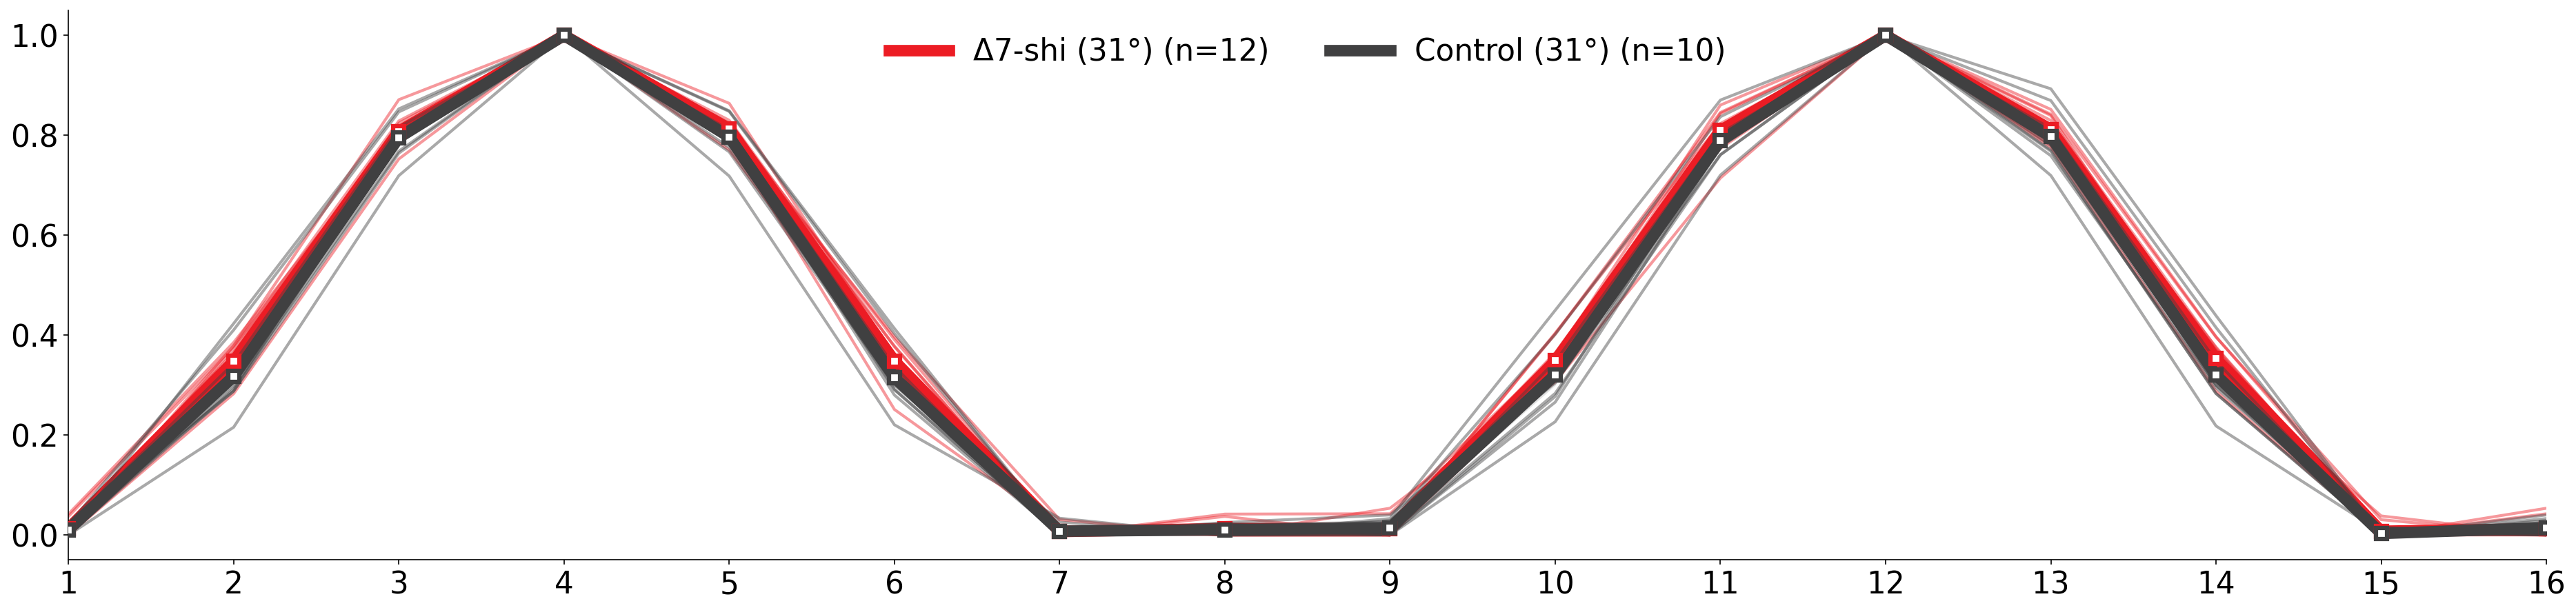

In [33]:
plot_phase_nulled_compare_per_fly_subsample8(
    phase_null_data_1, phase_null_data_2,
    labels=("Δ7-shi (31°)", "Control (31°)"),
    up=10,
    #colors=("#faa51a", "#282a74"),
    #colors=("#6A6A6A", "#2B8C83"),
    colors= ("#ec1c24","#404041"),
    prefer_aligned_source=True,
    align_mode='phase',
    align_target_glom=0,
    normalize_mode= 'minmax', 
    side_mode= "both_connected",# "separate" or "both_connected"
    show_fit=False,
    show_sem=True,
    lw_mean=8.0,
    per_fly_lw=2,             # NEW: per-fly line width
    per_fly_alpha=0.45,
    mean_marker="s",                 
    mean_marker_size=8,              
    mean_marker_edgewidth=3,   
)




In [53]:
#colors=("#faa51a", "#282a74") EPG and delta7 syt7f

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import mannwhitneyu

# ---------------- angle helpers (8 ROIs == 360°) ----------------
def _theta_8():
    """8 evenly spaced angles in radians over [0, 2π)."""
    return 2.0 * np.pi * (np.arange(8) / 8.0)

def _theta_fine(up=10):
    return 2.0 * np.pi * (np.linspace(0, 8, 8*up, endpoint=False) / 8.0)

# ---------------- subsample fine (8*up) → 8 ROIs ----------------
def subsample_fine_to_8(y_fine, up=10):
    y = np.asarray(y_fine, float).ravel()
    if y.size % 8 != 0:
        raise ValueError("fine profile length must be a multiple of 8.")
    return y[:: (y.size // 8)] if (y.size // 8) != 0 else y

# ---------------- cosine fit with fixed period 2π ----------------
def fit_cosine_fixed_period(theta, y):
    """
    y ≈ A*cos(theta - phi) + B, period fixed to 2π.
    Returns dict with A, offset, phi_rad (0..2π), phase_glom (0..8), R2, RMSE.
    """
    theta = np.asarray(theta, float)
    y = np.asarray(y, float)

    C = np.cos(theta); S = np.sin(theta)
    X = np.column_stack([C, S, np.ones_like(theta)])
    a, b, c = np.linalg.lstsq(X, y, rcond=None)[0]
    A = float(np.hypot(a, b))
    phi = float(np.arctan2(b, a)) % (2*np.pi)
    yhat = A * np.cos(theta - phi) + c

    resid = y - yhat
    sse = float(np.sum(resid**2))
    sst = float(np.sum((y - np.mean(y))**2))
    R2 = 1.0 - sse / sst if sst > 0 else np.nan
    RMSE = float(np.sqrt(np.mean(resid**2)))
    phase_glom = (phi / (2*np.pi)) * 8.0
    return {"A": A, "offset": c, "phi_rad": phi, "phase_glom": phase_glom % 8.0,
            "R2": R2, "RMSE": RMSE, "yhat": yhat}

# ---------------- von Mises fit (period = 2π) ----------------
def _vm_model(theta, A, kappa, phi, B):
    # y = A * exp(kappa * cos(theta - phi)) + B
    return A * np.exp(kappa * np.cos(theta - phi)) + B

def fit_vonmises(theta, y, init=None, bounds=None):
    theta = np.asarray(theta, float)
    y = np.asarray(y, float)

    # Good initial guesses from cosine fit:
    cf = fit_cosine_fixed_period(theta, y)
    A0 = max(1e-6, cf["A"])               # amplitude (>0)
    B0 = float(np.nanmin(y))              # baseline
    phi0 = cf["phi_rad"]
    kappa0 = 1.5                          # mild concentration

    p0 = (A0, kappa0, phi0, B0) if init is None else init
    # Keep parameters in sensible ranges
    bnds = ((0.0, 0.0, -2*np.pi, -np.inf),   # A>=0, kappa>=0
            (np.inf, 50.0,  2*np.pi,  np.inf)) if bounds is None else bounds

    try:
        popt, _ = curve_fit(_vm_model, theta, y, p0=p0, bounds=bnds, maxfev=20000)
        A, kappa, phi, B = map(float, popt)
        yhat = _vm_model(theta, A, kappa, phi, B)
    except Exception:
        # fallback: flat line to avoid crash
        A, kappa, phi, B = 0.0, 0.0, 0.0, float(np.nanmean(y))
        yhat = np.ones_like(y) * B

    resid = y - yhat
    sse = float(np.sum(resid**2))
    sst = float(np.sum((y - np.mean(y))**2))
    R2 = 1.0 - sse / sst if sst > 0 else np.nan
    RMSE = float(np.sqrt(np.mean(resid**2)))
    phase_glom = (phi / (2*np.pi)) * 8.0
    return {"A": A, "kappa": kappa, "offset": B, "phi_rad": phi,
            "phase_glom": phase_glom % 8.0, "R2": R2, "RMSE": RMSE, "yhat": yhat}

# ---------------- collect per-fly stacks from your fly_data dicts ----------------
def _base_id_from_trial(trial_id):
    return trial_id.rsplit("-", 1)[0] if isinstance(trial_id, str) and "-" in trial_id else trial_id

def _gather_group_objects(group_dict, side="left", up=10, prefer_fine_mean=True):
    """
    Returns dict: fly_id -> list of 8-vectors to fit.
    If stacks are available, uses 'phase_null_{side}_stack_8' (frames).
    Else falls back to the per-trial mean_fine, subsampled to 8.
    """
    fly_to_vectors = {}
    if group_dict is None:
        return fly_to_vectors

    stack_key = f"phase_null_{side}_stack_8"
    mean_fine_key = f"phase_null_{side}_mean_fine"

    for trial_id, d in group_dict.items():
        fid = _base_id_from_trial(trial_id)

        # prefer frames if available
        if stack_key in d and d[stack_key] is not None and len(d[stack_key]) > 0:
            mat = np.asarray(d[stack_key], float)
            # each row is an 8-vector
            for row in mat:
                if row.size == 8 and np.isfinite(row).all():
                    fly_to_vectors.setdefault(fid, []).append(row.astype(float))
            continue

        # fallback: use mean_fine (subsample to 8)
        if prefer_fine_mean and (mean_fine_key in d) and (d[mean_fine_key] is not None):
            y_fine = np.asarray(d[mean_fine_key], float).ravel()
            if y_fine.size == 8*up and np.isfinite(y_fine).all():
                fly_to_vectors.setdefault(fid, []).append(subsample_fine_to_8(y_fine, up=up))

    return fly_to_vectors

# ---------------- compute per-fly R²s under the two modes ----------------
def _compute_R2s_per_fly(fly_to_vectors, mode="per_fly_mean"):
    """
    mode:
      - 'per_fly_mean': average vectors per fly, fit once → one R² per fly.
      - 'per_frame_then_flyavg': fit each frame vector, average R² per fly.
    Returns: dicts R2_cos[fly], R2_vm[fly]
    """
    theta = _theta_8()
    R2_cos, R2_vm = {}, {}

    for fid, vectors in fly_to_vectors.items():
        V = np.asarray(vectors, float)
        if V.ndim != 2 or V.shape[1] != 8:
            continue

        if mode == "per_fly_mean":
            y = np.nanmean(V, axis=0)
            c = fit_cosine_fixed_period(theta, y)["R2"]
            v = fit_vonmises(theta, y)["R2"]
            R2_cos[fid] = c
            R2_vm[fid]  = v

        elif mode == "per_frame_then_flyavg":
            r2c_list, r2v_list = [], []
            for y in V:
                if not np.isfinite(y).all():
                    continue
                r2c_list.append(fit_cosine_fixed_period(theta, y)["R2"])
                r2v_list.append(fit_vonmises(theta, y)["R2"])
            if len(r2c_list):
                R2_cos[fid] = float(np.nanmean(r2c_list))
            if len(r2v_list):
                R2_vm[fid]  = float(np.nanmean(r2v_list))

        else:
            raise ValueError("mode must be 'per_fly_mean' or 'per_frame_then_flyavg'.")

    return R2_cos, R2_vm

# ---------------- plotting: two panels (Cosine, Von Mises) with swarm + mean±SEM ----------------
def _swarm_with_mean(ax, data, x, width=0.25, color="k", mfc="white", label=None):
    rng = np.random.default_rng(0)
    n = len(data)
    jitter = (rng.random(n) - 0.5) * width
    ax.plot(np.full(n, x) + jitter, data, 'o', ms=6, mec=color, mfc=mfc, alpha=0.9)
    if n:
        mean = float(np.nanmean(data))
        sem  = float(np.nanstd(data, ddof=1)/np.sqrt(n)) if n > 1 else 0.0
        ax.errorbar([x], [mean], yerr=[sem], fmt='s', color='red', ecolor='red',
                    elinewidth=2, capsize=4, ms=7, label=label if label else None)
    return ax

def compare_goodness_of_fit_cosine_vs_vonmises(
    group1, group2,
    side="left",
    mode="per_fly_mean",       # 'per_fly_mean' | 'per_frame_then_flyavg'
    up=10,
    group_labels=("Group 1", "Group 2"),
    figsize=(11,5),
    y_lim=(0, 1.0),
    show_stats=True,
    alpha=0.05
):
    """
    Produces a figure with two panels:
      Left: R² (Cosine) for Group 1 vs Group 2
      Right: R² (Von Mises) for Group 1 vs Group 2

    R²s are computed either on each fly's mean (mode='per_fly_mean') or
    by fitting each frame and averaging per fly (mode='per_frame_then_flyavg').
    """
    # 1) Gather frames/means per fly
    g1 = _gather_group_objects(group1, side=side, up=up, prefer_fine_mean=True)
    g2 = _gather_group_objects(group2, side=side, up=up, prefer_fine_mean=True)

    # 2) Compute R² sets
    g1_cos, g1_vm = _compute_R2s_per_fly(g1, mode=mode)
    g2_cos, g2_vm = _compute_R2s_per_fly(g2, mode=mode)

    d1c = np.array(list(g1_cos.values()), float)
    d2c = np.array(list(g2_cos.values()), float)
    d1v = np.array(list(g1_vm.values()),  float)
    d2v = np.array(list(g2_vm.values()),  float)

    # 3) Stats
    def _mw(a, b):
        if a.size and b.size:
            try:
                return mannwhitneyu(a, b, alternative="two-sided").pvalue
            except Exception:
                return np.nan
        return np.nan

    p_cos = _mw(d1c, d2c)
    p_vm  = _mw(d1v, d2v)

    # 4) Plot
    fig, axs = plt.subplots(1, 2, figsize=figsize, dpi=150, sharey=True)
    titles = [f"Cosine (mode: {mode})", f"Von Mises (mode: {mode})"]

    for ax, d1, d2, title, pval in zip(
        axs, (d1c, d1v), (d2c, d2v), titles, (p_cos, p_vm)
    ):
        ax.set_title(title)
        _swarm_with_mean(ax, d1, x=0, color="k", mfc="white", label=f"{group_labels[0]} mean±SEM")
        _swarm_with_mean(ax, d2, x=1, color="k", mfc="white", label=f"{group_labels[1]} mean±SEM")
        ax.set_xlim(-0.5, 1.5)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(group_labels)
        ax.set_ylabel(r"$R^2$")
        ax.set_ylim(*y_lim)

        # significance bar
        if show_stats and np.isfinite(pval):
            ytop = np.nanmax(np.concatenate([d1, d2])) if (d1.size or d2.size) else 0.0
            ybar = ytop + 0.05*(y_lim[1]-y_lim[0])
            ax.plot([0,0,1,1], [ybar, ybar+0.02, ybar+0.02, ybar], color='k', lw=1.5)
            star = "*" if pval < alpha else "n.s."
            ax.text(0.5, ybar+0.03, star, ha='center', va='bottom', fontsize=12)

        ax.legend(frameon=False, loc="lower right", fontsize=9)

    fig.suptitle(f"Goodness-of-fit comparison ({side} PB)", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

    # 5) Return raw numbers in case you want to save/inspect
    return {
        "group1": {"cosine_R2_by_fly": d1c, "vonmises_R2_by_fly": d1v},
        "group2": {"cosine_R2_by_fly": d2c, "vonmises_R2_by_fly": d2v},
        "p_values": {"cosine": p_cos, "vonmises": p_vm},
        "mode": mode,
        "side": side
    }


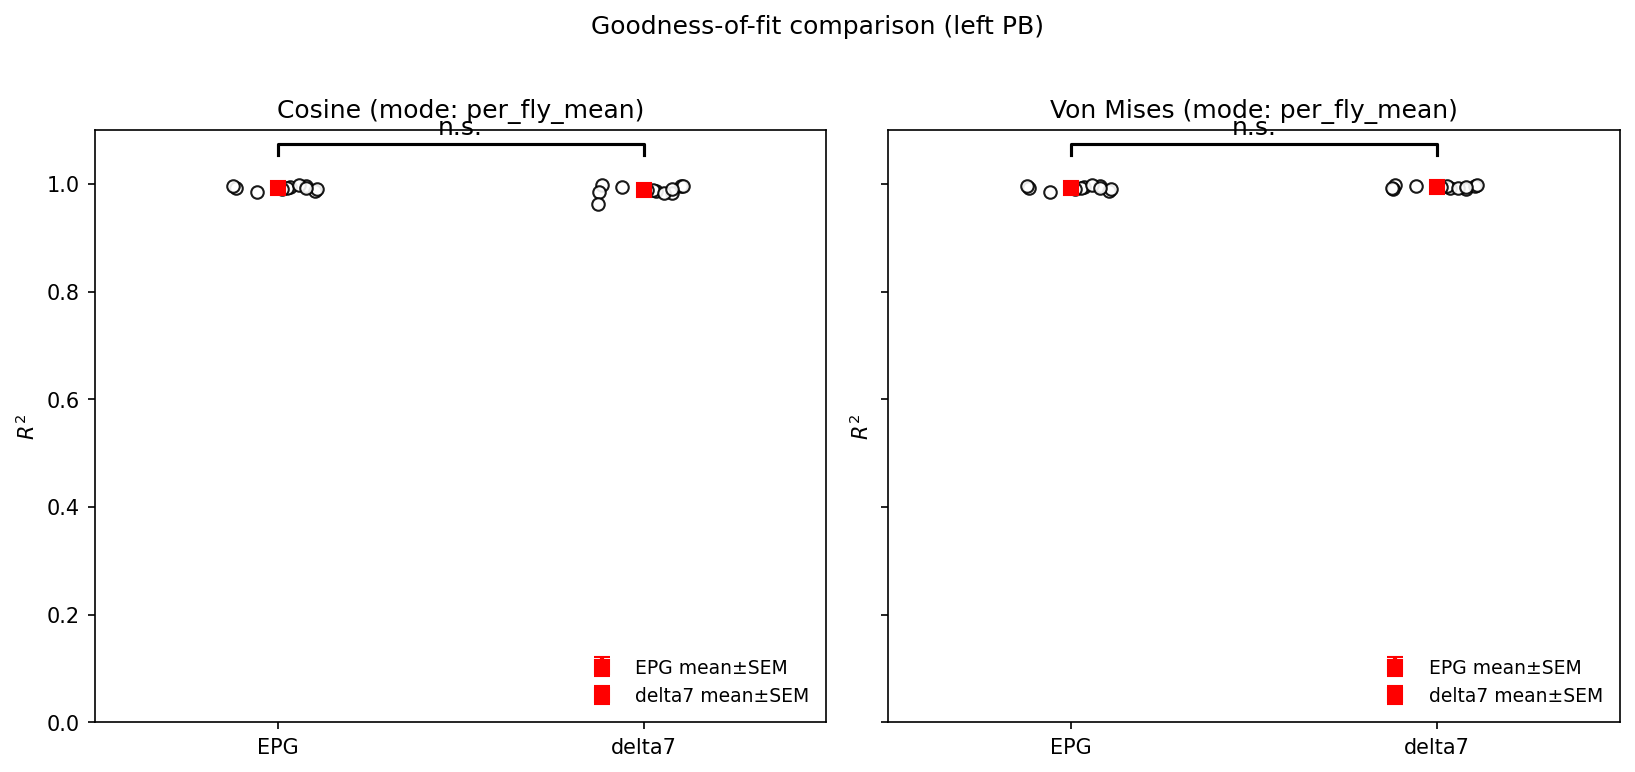

In [91]:
out = compare_goodness_of_fit_cosine_vs_vonmises(
    group1=phase_null_data_1,     # your dict for group 1
    group2=phase_null_data_2,     # your dict for group 2
    side="left",                  # or "right"
    mode="per_fly_mean",          # <- one fit per fly
    group_labels=("EPG", "delta7"),
    y_lim=(0, 1.1)
)


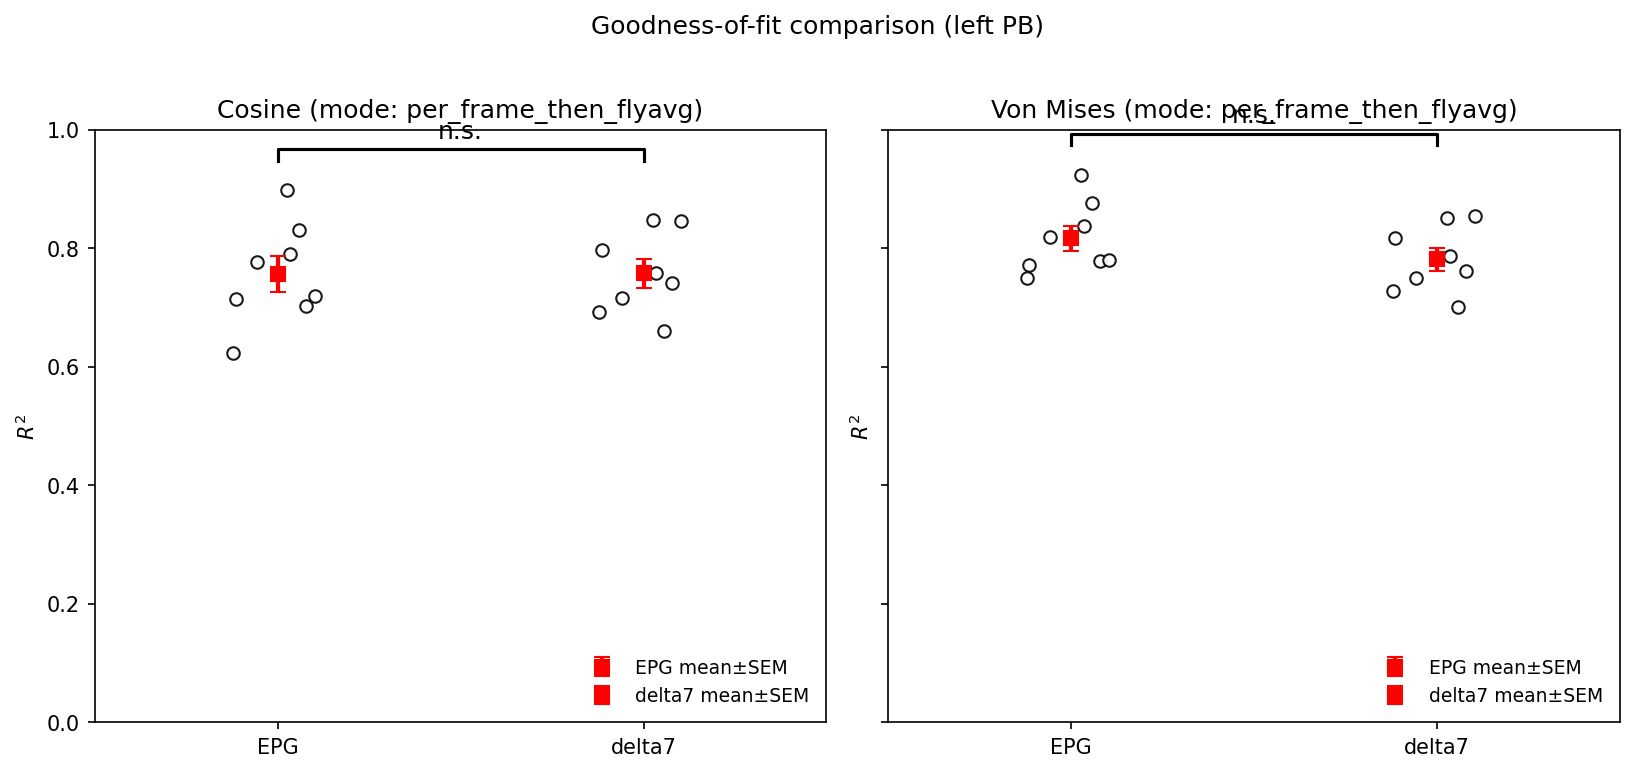

In [39]:
out = compare_goodness_of_fit_cosine_vs_vonmises(
    group1=phase_null_data_1,
    group2=phase_null_data_2,
    side="left",
    mode="per_frame_then_flyavg", # <- frame-level fits, averaged per fly
    group_labels=("EPG", "delta7")
)


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ---- your 8-ROI FWHM (unchanged) ----
def fwhm_from_8rois(y8):
    y = np.asarray(y8, float).ravel()
    if y.size != 8 or not np.isfinite(y).all():
        return np.nan
    y0 = y - np.nanmin(y)
    ymax = np.nanmax(y0)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    half = 0.5 * ymax
    z = y0 - half
    crossings = []
    for i in range(8):
        j = (i + 1) % 8
        z1, z2 = z[i], z[j]
        if np.isclose(z1, 0.0):
            crossings.append(float(i))
        if z1 * z2 < 0.0:
            denom = (z2 - z1)
            if not np.isclose(denom, 0.0):
                t = (-z1) / denom
                crossings.append(i + float(t))
    crossings = np.array(sorted(crossings))
    if crossings.size == 0: return np.nan
    keep = [0]
    for k in range(1, crossings.size):
        if abs(crossings[k] - crossings[keep[-1]]) > 1e-6:
            keep.append(k)
    crossings = crossings[keep]
    if crossings.size < 2: return np.nan
    i_max = int(np.argmax(y0))
    best_width = None
    m = crossings.size
    for k in range(m):
        a = crossings[k]
        b = crossings[(k + 1) % m]
        width = b - a if b > a else (b + 8.0) - a
        i_rel = i_max if i_max >= a else i_max + 8.0
        if (a <= i_rel) and (i_rel < a + width):
            best_width = width
            break
    if best_width is None:
        best_width = min([(crossings[(k+1)%m] - crossings[k]) % 8.0 for k in range(m)])
    return best_width * (360.0 / 8.0)

# optional: use fine means if present but only 8 matters for FWHM here
def _get_mean8(d, side, up=10):
    y8 = d.get(f'phase_null_{side}_mean_8', None)
    if y8 is not None:
        y8 = np.asarray(y8, float).ravel()
        if y8.size == 8 and np.all(np.isfinite(y8)):
            return y8
    yfine = d.get(f'phase_null_{side}_mean_fine', None)
    if yfine is not None:
        yfine = np.asarray(yfine, float).ravel()
        if yfine.size % 8 == 0:
            return yfine[::up]  # subsample to 8
    return None

def compute_fwhm_values(
    fly_group_dict,
    *,
    per_fly=True,            # True: average trials per biological fly; False: each trial as a separate point
    bridge_mode="combined",  # "combined" | "avg_fwhm" | "separate"
    up=10
):
    """
    Returns (ids, values):
      ids: list of labels per datum (fly id, trial id, or with ':L'/'R' when bridge_mode='separate')
      values: np.array of FWHM degrees
    """
    if not fly_group_dict:
        return [], np.array([])

    # bucket by fly or by trial
    buckets = {}
    for trial_id, d in fly_group_dict.items():
        key = trial_id.rsplit("-", 1)[0] if (per_fly and "-" in trial_id) else trial_id
        buckets.setdefault(key, []).append((trial_id, d))

    out_ids, out_vals = [], []

    for key, items in buckets.items():
        # collect per-side 8-bin means for all trials in this bucket
        L_list, R_list = [], []
        for _, d in items:
            y8L = _get_mean8(d, "left", up=up)
            y8R = _get_mean8(d, "right", up=up)
            if y8L is not None: L_list.append(y8L)
            if y8R is not None: R_list.append(y8R)

        # average across trials in the bucket (if per_fly=True there may be >1)
        y8L_mean = np.nanmean(np.vstack(L_list), axis=0) if len(L_list) else None
        y8R_mean = np.nanmean(np.vstack(R_list), axis=0) if len(R_list) else None

        if bridge_mode == "combined":
            profiles = [p for p in (y8L_mean, y8R_mean) if p is not None]
            if not profiles: continue
            y8 = np.nanmean(np.vstack(profiles), axis=0)
            f = fwhm_from_8rois(y8)
            if np.isfinite(f):
                out_ids.append(key); out_vals.append(f)

        elif bridge_mode == "avg_fwhm":
            fL = fwhm_from_8rois(y8L_mean) if y8L_mean is not None else np.nan
            fR = fwhm_from_8rois(y8R_mean) if y8R_mean is not None else np.nan
            if np.isfinite(fL) and np.isfinite(fR):
                f = 0.5*(fL+fR)
            else:
                f = fL if np.isfinite(fL) else fR
            if np.isfinite(f):
                out_ids.append(key); out_vals.append(f)

        elif bridge_mode == "separate":
            # produce separate points for L and R
            if y8L_mean is not None:
                fL = fwhm_from_8rois(y8L_mean)
                if np.isfinite(fL):
                    out_ids.append(f"{key}:L"); out_vals.append(fL)
            if y8R_mean is not None:
                fR = fwhm_from_8rois(y8R_mean)
                if np.isfinite(fR):
                    out_ids.append(f"{key}:R"); out_vals.append(fR)

        else:
            raise ValueError("bridge_mode must be one of: 'combined', 'avg_fwhm', 'separate'")

    return out_ids, np.asarray(out_vals, float)

def plot_fwhm_groups(
    data1, data2=None, *,
    labels=("Group 1","Group 2"),
    colors=("#527a92","#e77c87"),
    per_fly=True,
    bridge_mode="combined",   # "combined" | "avg_fwhm" | "separate"
    up=10,
    test="mannwhitney"        # "mannwhitney" | None
):
    """
    Scatter each group's FWHM (°) with group mean±SEM and (optional) Mann–Whitney U test.
    """
    rng = np.random.default_rng(3)
    groups = []
    ids1, v1 = compute_fwhm_values(data1, per_fly=per_fly, bridge_mode=bridge_mode, up=up)
    groups.append((labels[0], colors[0], ids1, v1))
    if data2 is not None:
        ids2, v2 = compute_fwhm_values(data2, per_fly=per_fly, bridge_mode=bridge_mode, up=up)
        groups.append((labels[1], colors[1], ids2, v2))

    # x positions (categorical)
    xs = np.arange(1, len(groups)+1, dtype=float)

    plt.figure(figsize=(8.5,5.0), dpi=150)
    ymax = -np.inf
    for x, (name, color, ids, vals) in zip(xs, groups):
        if vals.size == 0: continue
        jitter = (rng.random(vals.size) - 0.5) * 0.20
        plt.scatter(np.full(vals.size, x) + jitter, vals, s=42, color=color, alpha=0.9)
        mean = np.nanmean(vals)
        sem  = np.nanstd(vals, ddof=1)/np.sqrt(vals.size) if vals.size>1 else 0.0
        plt.errorbar(x, mean, yerr=sem, fmt='o', color='k', ms=6, lw=2, capsize=4, zorder=5)
        ymax = max(ymax, np.max(vals), mean+sem)

    # Mann–Whitney bracket if 2 groups
    if test == "mannwhitney" and len(groups) == 2 and groups[0][3].size and groups[1][3].size:
        a = groups[0][3]; b = groups[1][3]
        stat, pval = stats.mannwhitneyu(a, b, alternative='two-sided')
        yb = ymax + 3
        x1, x2 = xs[0], xs[1]
        plt.plot([x1, x1, x2, x2], [yb, yb+2.5, yb+2.5, yb], color='k', lw=1.8)
        stars = "***" if pval < 1e-3 else ("**" if pval < 1e-2 else ("*" if pval < 0.05 else "n.s."))
        plt.text((x1+x2)/2, yb+3.2, stars, ha='center', va='bottom', fontsize=14)

    # cosmetics
    xticklabels = [f"{g[0]}\n(n={g[3].size})" for g in groups]
    plt.xticks(xs, xticklabels)
    plt.xlim(0.5, len(groups)+0.5)
    plt.ylabel("FWHM (°)")
    plt.xlabel("")  # just the group labels
    plt.title("mean FWHM")
    plt.tight_layout()
    plt.show()


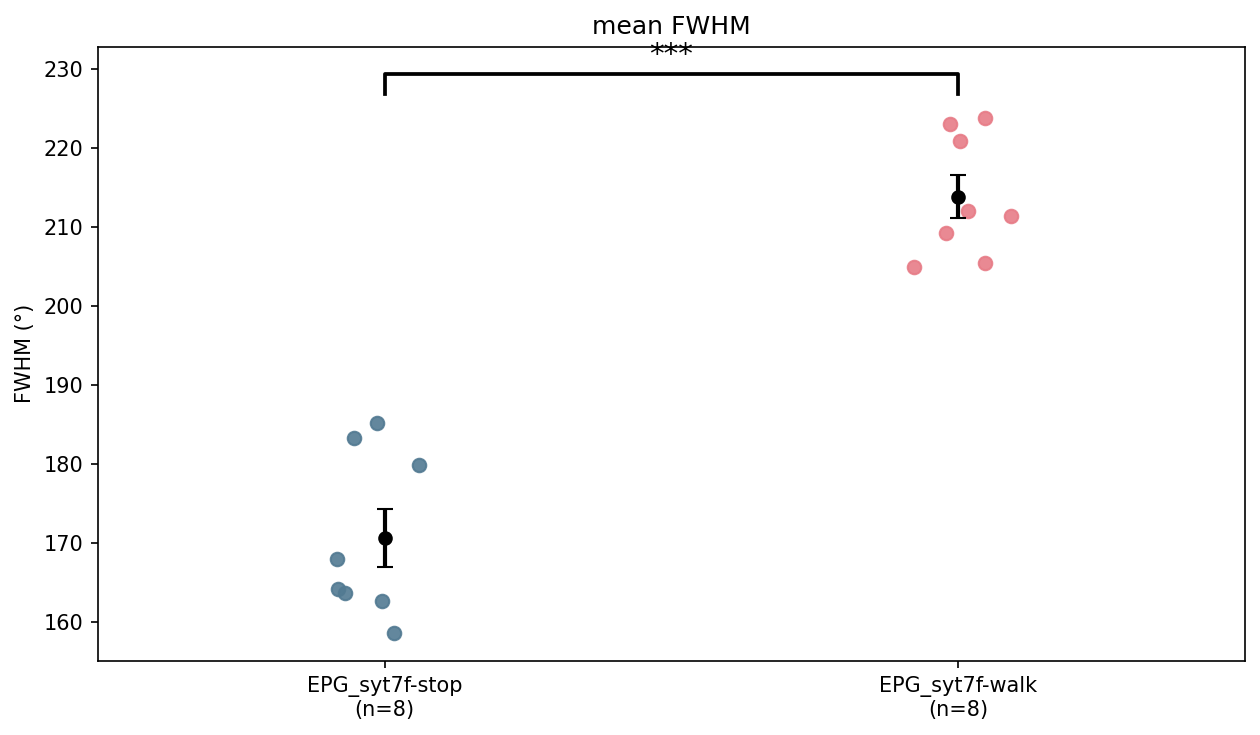

In [33]:
plot_fwhm_groups(
    phase_null_data_1, phase_null_data_2,
    labels=("EPG_syt7f-stop","EPG_syt7f-walk"),
    per_fly=True,
    bridge_mode="combined",   # combine L+R before FWHM
    up=10
)



In [34]:
def make_roi_axis_heat(ax):
    ax.set_xticks(np.arange(8))
    ax.set_xticklabels([str(i) for i in range(1,9)])
    ax.set_xlabel("Glomerulus (1–8)")
    return ax


def _per_fly_matrix_8(
    group_dict, side="left", up=10,
    align_mode="none",                 # NEW: "none" | "peak" | "phase"
    align_target_glom=4.0,             # where to put the peak/phase
    normalize="none",                  # "none" | "minmax" | "peak"
    prefer_aligned_source=True,
    sort_rows=True
):
    """
    Build an (n_flies × 8) matrix for one group/side.
    Returns (fly_ids, M), where M[i,:] is that fly's 8-ROI profile.
    """
    fly_ids, stack, per_fly = _collect_per_fly_mean(
        group_dict, side=side, up=up, prefer_aligned_source=prefer_aligned_source
    )
    if stack is None or stack.size == 0:
        return [], np.empty((0,8))

    rows = []
    peak_positions = []
    for fid in fly_ids:
        y_fine = np.asarray(per_fly[fid], float).ravel()

        # ---- NEW alignment modes ----
        if align_mode == "peak" and align_target_glom is not None:
            y_fine = _peak_align_profile(y_fine, up=up,
                                         target_center_glom=float(align_target_glom))
        elif align_mode == "phase" and align_target_glom is not None:
            shift_bins = float(align_target_glom) * up
            y_fine = _circ_shift_fractional(y_fine, shift_bins)

        y8 = subsample_fine_to_8(y_fine, up=up)

        # ---- normalization options ----
        if normalize == "minmax":
            y8 = y8 - np.nanmin(y8)
            rng = np.nanmax(y8)
            if np.isfinite(rng) and rng > 0:
                y8 = y8 / rng
        elif normalize == "peak":
            pk = np.nanmax(y8)
            if np.isfinite(pk) and pk > 0:
                y8 = y8 / pk

        rows.append(y8)
        peak_positions.append(np.nanargmax(y8))

    M = np.vstack(rows)

    if sort_rows and M.shape[0] > 1:
        order = np.argsort(peak_positions)
        M = M[order, :]
        fly_ids = [fly_ids[i] for i in order]

    return fly_ids, M


def plot_phase_nulled_heatmaps(
    data1, data2=None, data3=None, data4=None,
    labels=("Group 1", "Group 2", "Group 3", "Group 4"),
    sides=("left","right"),
    up=10,
    align_mode="none",                # NEW
    align_target_glom=4.0,            # NEW
    normalize="minmax",
    prefer_aligned_source=True,
    cmap="viridis",
    share_color=True,
    sort_rows=True,
    fontsize=12
):
    """
    Make 1–4 heatmaps, one per provided group dict.
    Each panel shows an n_flies × 8 matrix (rows=flies, cols=glomeruli).
    Returns a dict with per-group matrices and fly IDs.
    """
    groups = [g for g in (data1, data2, data3, data4) if g is not None]
    glabels = labels[:len(groups)]
    out = {}

    per_side_mats = {side: [] for side in sides}
    per_side_meta = {side: [] for side in sides}
    for side in sides:
        for g, lab in zip(groups, glabels):
            fly_ids, M = _per_fly_matrix_8(
                g, side=side, up=up,
                align_mode=align_mode, align_target_glom=align_target_glom,
                normalize=normalize, prefer_aligned_source=prefer_aligned_source,
                sort_rows=sort_rows
            )
            per_side_mats[side].append(M)
            per_side_meta[side].append((lab, fly_ids))
            out[(lab, side)] = {"fly_ids": fly_ids, "matrix": M}

    for side in sides:
        n_panels = len(per_side_mats[side])
        if n_panels == 0:
            continue

        if share_color:
            if normalize in ("minmax","peak"):
                vmin, vmax = 0.0, 1.0
            else:
                vmin = min((np.nanmin(M) for M in per_side_mats[side] if M.size), default=0.0)
                vmax = max((np.nanmax(M) for M in per_side_mats[side] if M.size), default=1.0)
        else:
            vmin = vmax = None

        fig, axes = plt.subplots(1, n_panels, figsize=(4.5*n_panels, 4.8), dpi=140, squeeze=False)
        axes = axes[0]

        for ax, M, (lab, fly_ids) in zip(axes, per_side_mats[side], per_side_meta[side]):
            if M.size == 0:
                ax.set_axis_off()
                ax.set_title(f"{lab} ({side}) — no data", fontsize=fontsize)
                continue

            _vmin, _vmax = (vmin, vmax)
            if not share_color:
                if normalize in ("minmax","peak"):
                    _vmin, _vmax = 0.0, 1.0
                else:
                    _vmin, _vmax = float(np.nanmin(M)), float(np.nanmax(M))

            im = ax.imshow(M, aspect="auto", cmap=cmap, vmin=_vmin, vmax=_vmax,
                           interpolation="nearest", origin="upper")
            make_roi_axis_heat(ax)
            ax.set_yticks(np.arange(M.shape[0]))
            ax.set_yticklabels([str(i+1) for i in range(M.shape[0])], fontsize=fontsize-2)
            ax.set_ylabel("Flies (per-fly mean)", fontsize=fontsize)
            n_str = f"(n={M.shape[0]})"
            ax.set_title(f"{lab} — {side} {n_str}", fontsize=fontsize+2)

            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.ax.tick_params(labelsize=fontsize-2)
            cbar.set_label("Activity", fontsize=fontsize)

            ax.tick_params(axis='both', which='major', labelsize=fontsize-2)

        plt.tight_layout()
        plt.show()

    return out



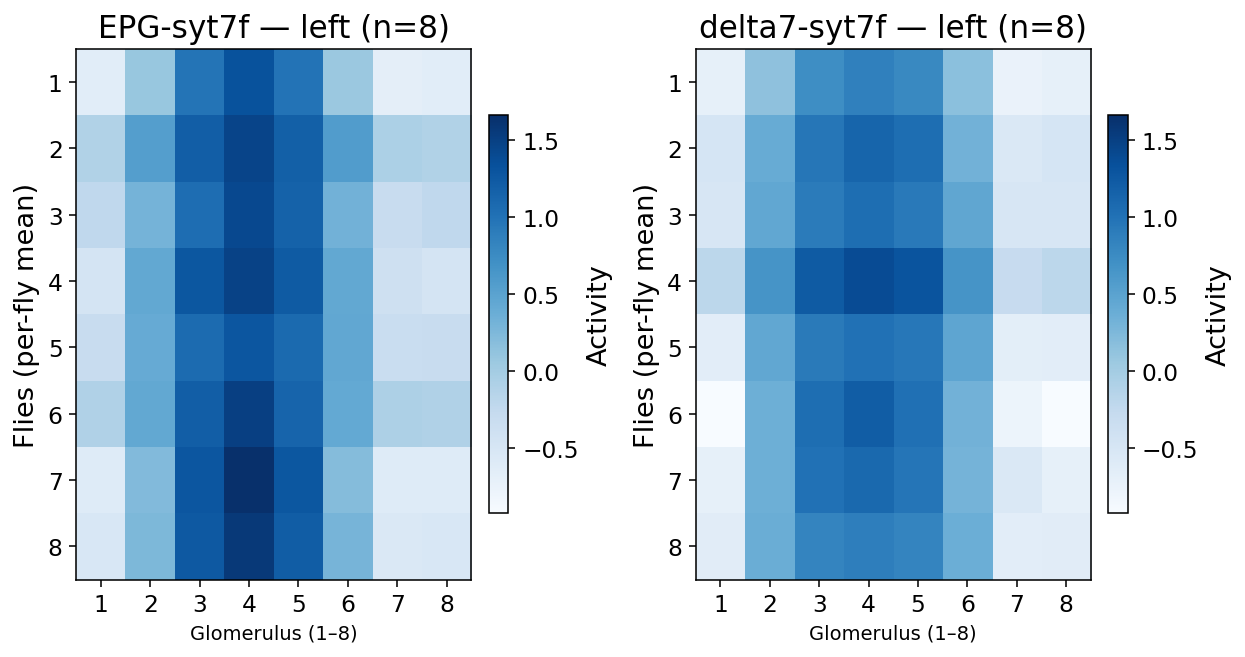

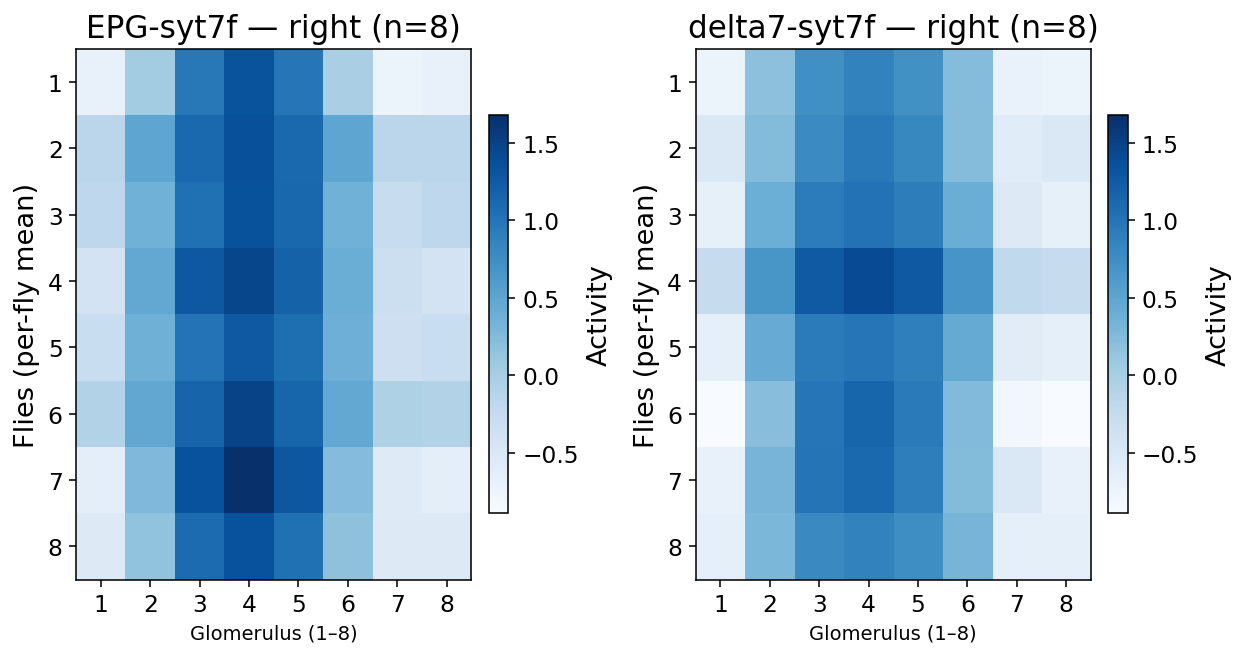

In [35]:
# Example: compare two groups, make left+right heatmaps
results = plot_phase_nulled_heatmaps(
    data1=phase_null_data_1,
    data2=phase_null_data_2,
    labels=("EPG-syt7f", "delta7-syt7f"),
    sides=("left","right"),        # make heatmaps for both sides
    up=10,
    align_mode=None,
    align_target_glom=3,        # align each fly’s peak to glomerulus 4
    normalize=None,            # scale each fly row to 0–1
    cmap="Blues",                  # colormap choice
    share_color=True,              # same scale for both groups
    sort_rows=True,
    fontsize=14
)
